# Machine Learning
Author: Scottie Housholder  
Course: MAT 311  
Updated: November 17, 2025#TODO:

In [926]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import randint

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import roc_auc_score

train_data = pd.read_csv("../data/processed/train_cleaned_temp.csv", index_col=0)
test_data = pd.read_csv("../data/processed/test_cleaned_temp.csv", index_col=0)

In [927]:
def find_k(size):
    """
    Return the number of neighbors a KNN algorithm should have
    Returns the square root of the given number and makes sure it's odd
    """

    k = round(size**0.5)
    if k % 2 == 0:
        return k-1
    return k

In [928]:
X = train_data[['Support Calls', "Contract Length_Monthly", "Payment Delay", "Total Spend", "Age"]]
y = train_data["Churn"]
X_train1, X_test1, y_train1, y_test1 = train_test_split(X, y, test_size=0.2, random_state=754)

In [929]:
#Do not run this cell. It'll take absolutely forever
#Do not run this cell. It'll take absolutely forever
#Do not run this cell. It'll take absolutely forever



# param_dist = {
#   'n_estimators': randint(200, 500),
#   'max_depth': randint(4, 16),
#   'min_samples_split': randint(1, 12),
#   'min_samples_leaf': randint(1, 5)
# }

# # Create a random forest classifier
# rf = RandomForestClassifier(random_state=52, n_jobs=-1)

# # Use random search to find the best hyperparameters
# rand_search = RandomizedSearchCV(
#   rf, param_distributions=param_dist,
#   n_iter=5, cv=5, scoring='roc_auc',
#   n_jobs=-1, random_state=42
# )

# rand_search.fit(X_train1, y_train1)

# # Print the best hyperparameters
# print('Best hyperparameters:',  rand_search.best_params_)
# print('Best Score:',  rand_search.best_score_)

In [930]:
# knn = KNeighborsClassifier(find_k(len(test_data)))
forest = RandomForestClassifier(max_depth=10, min_samples_leaf=4, min_samples_split=11, n_estimators=271, n_jobs=-1)
# knn_fit1 = knn1.fit(X_train1, y_train1)
forest_fit1 = forest.fit(X_train1, y_train1)
prediction1 = forest_fit1.predict_proba(X_test1)[:, 1]
roc_auc_score(y_test1, prediction1)

0.9376899045845514

In [931]:
print(train_data.corrwith(train_data["Churn"]).sort_values())

Total Spend                  -0.372350
Contract Length_Quarterly    -0.141252
Contract Length_Annual       -0.138528
Usage Frequency              -0.049018
Tenure                       -0.019322
Subscription Type_Premium    -0.010027
Subscription Type_Standard   -0.006670
CustomerID                    0.001484
Subscription Type_Basic       0.016940
Last Interaction              0.104900
Gender_Female                 0.158337
Age                           0.189481
Payment Delay                 0.329147
Contract Length_Monthly       0.401125
Support Calls                 0.471295
Churn                         1.000000
Customer Status_inactive      1.000000
dtype: float64


In [932]:
train_data.columns

Index(['CustomerID', 'Age', 'Tenure', 'Usage Frequency', 'Support Calls',
       'Payment Delay', 'Total Spend', 'Last Interaction', 'Churn',
       'Gender_Female', 'Subscription Type_Basic', 'Subscription Type_Premium',
       'Subscription Type_Standard', 'Contract Length_Annual',
       'Contract Length_Monthly', 'Contract Length_Quarterly',
       'Customer Status_inactive'],
      dtype='object')

In [933]:
X_train = train_data[['Support Calls', "Contract Length_Monthly", "Payment Delay", "Total Spend", "Age"]]
X_test = test_data[['Support Calls', "Contract Length_Monthly", "Payment Delay", "Total Spend", "Age"]]
y_train = train_data["Churn"]
train_data.isna().sum()

CustomerID                    0
Age                           0
Tenure                        0
Usage Frequency               0
Support Calls                 0
Payment Delay                 0
Total Spend                   0
Last Interaction              0
Churn                         0
Gender_Female                 0
Subscription Type_Basic       0
Subscription Type_Premium     0
Subscription Type_Standard    0
Contract Length_Annual        0
Contract Length_Monthly       0
Contract Length_Quarterly     0
Customer Status_inactive      0
dtype: int64

In [934]:
# knn_fit = knn.fit(X_train, y_train)
forest_fit = forest.fit(X_train, y_train)

cols = X_train.columns

# knn_fit

In [935]:
test_data.columns

Index(['CustomerID', 'Age', 'Tenure', 'Usage Frequency', 'Support Calls',
       'Payment Delay', 'Total Spend', 'Last Interaction', 'Gender_Female',
       'Subscription Type_Basic', 'Subscription Type_Premium',
       'Subscription Type_Standard', 'Contract Length_Annual',
       'Contract Length_Monthly', 'Contract Length_Quarterly'],
      dtype='object')

In [936]:
# prob_predict = pd.DataFrame(knn_fit.predict_proba(X_test))
prob_predict = pd.DataFrame(forest_fit.predict_proba(X_test))
prob_predict["CustomerID"] = test_data["CustomerID"]
prob_predict = prob_predict.set_index("CustomerID")
prob_predict

,0,1
CustomerID,,
262106,0.341231,0.658769
37061,0.317314,0.682686
361832,0.343672,0.656328
425516,0.142033,0.857967
60597,0.285532,0.714468
...,...,...
396573,0.328603,0.671397
452602,0.156387,0.843613
424958,0.057747,0.942253


In [937]:
prob_predict = prob_predict.rename(columns={1:"Churn"})
prob_predict = prob_predict.drop(0, axis=1)
print(prob_predict)

               Churn
CustomerID          
262106      0.658769
37061       0.682686
361832      0.656328
425516      0.857967
60597       0.714468
...              ...
396573      0.671397
452602      0.843613
424958      0.942253
242104      0.655571
132430      0.666993

[133776 rows x 1 columns]


In [938]:
print(prob_predict["Churn"].unique())
print(prob_predict["Churn"].nunique())

[0.65876948 0.68268594 0.65632765 ... 0.9422528  0.65557072 0.66699338]
132129


In [939]:
prob_predict.head()

,Churn
CustomerID,
262106,0.658769
37061,0.682686
361832,0.656328
425516,0.857967
60597,0.714468


In [940]:
prob_predict.to_csv("../submission.csv")

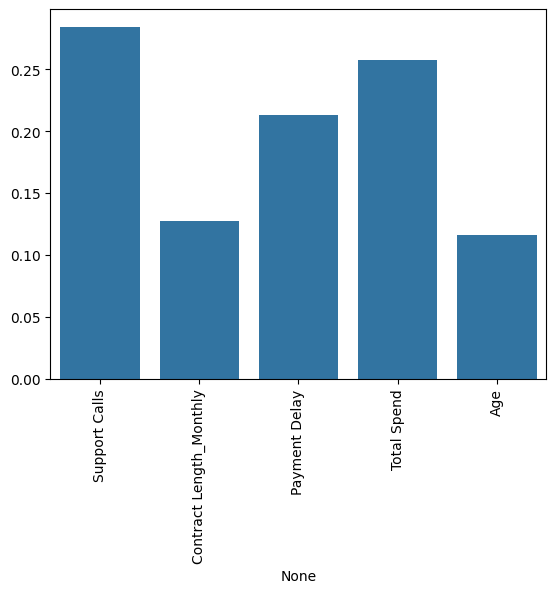

In [941]:
sns.barplot(x=cols, y=forest_fit.feature_importances_)
plt.xticks(rotation=90)
plt.show()